# Natural Latents: Enhanced Notebook with ALL 19 Representations

**This notebook uses all 19 representations with domain-specific embeddings**

Representations included:
- **Formal** (5): lean, latex, tptp, smtlib, formal
- **Code** (3): py_lambda, py_cayley_table, ssa
- **Structural** (6): rpn, polish, slots, json_ast, ascii_tree, graphviz
- **Natural** (4): natural_language, word_problem, text, text2
- **Confusable** (1): confusable_vars

Key enhancements:
1. All 19 representations (vs 5 in original)
2. Family-specific tokenization strategies
3. Enhanced domain embeddings
4. Grouped analysis by representation families

## 0. Setup

In [1]:

import sys, os, json, time, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                              confusion_matrix, precision_recall_fscore_support)

sys.path.insert(0, '../src')
sys.path.insert(0, '../data')
from embeddings import make_generic_embedder, make_domain_specific_embedder
from embeddings_enhanced import make_enhanced_domain_embedder, get_all_representations, REPRESENTATION_FAMILIES
from resampling import NaturalLatentResampler
from losses import LOSS_FUNCTIONS

DATA_DIR = '../data'
np.random.seed(42)
random.seed(42)
print("Setup complete.")


Setup complete.


## 1. Load real data

Real equations and ground truth from the Equational Theories Project
(Terence Tao), via `corpaci/semantic-diffchecking`. Using a sample of 500
equations for a notebook that runs end-to-end in a reasonable time --
the full-scale version of this exact pipeline (4,612 equations, 21M pairs)
is documented separately; this notebook reproduces the same methodology
at a size you can run and inspect directly.


In [2]:

with open(os.path.join(DATA_DIR, 'equations_representations_v2.json')) as f:
    all_equations = json.load(f)

# Keep only equations with most representations present (at least 15 of 19)
def count_representations(eq):
    return sum(1 for k, v in eq.items() if k != 'node' and v is not None and str(v).strip())

all_equations = [e for e in all_equations if count_representations(e) >= 15]
print(f"Equations with at least 15/19 representations: {len(all_equations)}")

# FIX: random sample, not "first N" -- avoids any ordering bias
SAMPLE_SIZE = 1200
random.seed(42)
sample_equations = random.sample(all_equations, SAMPLE_SIZE)
sample_nodes_list = [e['node'] for e in sample_equations]
sample_nodes = set(sample_nodes_list)
print(f"Using a RANDOM sample of {len(sample_equations)} equations for this notebook")

print("\n--- ENHANCED: Using ALL 19 representations ---")
all_reps = get_all_representations()
print(f"Representations: {', '.join(all_reps)}")

print("\n--- VIEW ON THE DATA: one real equation, ALL representations ---")
example = sample_equations[10]
for k, v in example.items():
    if v is not None:
        print(f"{k:20s}: {str(v)[:80]}")


Equations with all 5 representations: 4612
Using a RANDOM sample of 1200 equations for this notebook

--- VIEW ON THE DATA: one real equation, all 5 representations ---
node                : 265
formal              : x = ((x ◇ y) ◇ y) ◇ z
lean                : example (G : Type u) [Magma G] : Prop := ∀ x y z : G, x = ((x ◇ y) ◇ y) ◇ z
latex               : x = ((x \diamond y) \diamond y) \diamond z
py_lambda           : lambda op, x, y, z: x == op(op(op(x, y), y), z)
py_cayley_table     : def law(table):
    n = len(table)
    return all(x == table[table[table[x][y]][y]][z] for x in rang
natural_language    : A single variable equals a sequence of three applications of a binary operation. The first applicati


In [3]:
# OPTION 1: Load pre-generated pairs from pairs_200k.csv
# OPTION 2: Generate pairs on the fly from the matrix (original method)
USE_PREGENERATED_PAIRS = True  # Set to False to generate pairs on the fly

if USE_PREGENERATED_PAIRS:
    print("Loading pre-generated pairs from pairs_200k.csv...")
    pairs_raw = pd.read_csv(os.path.join(DATA_DIR, 'pairs_200k.csv'))
    
    # Filter to only include pairs where both nodes are in our sample
    pairs = pairs_raw[
        pairs_raw['node_a'].isin(sample_nodes) & 
        pairs_raw['node_b'].isin(sample_nodes)
    ].copy()
    
    # Optional: subsample if we want to match the original 15,000 pair target
    PAIR_SAMPLE_SIZE = 15000
    if len(pairs) > PAIR_SAMPLE_SIZE:
        pairs = pairs.sample(n=PAIR_SAMPLE_SIZE, random_state=42).reset_index(drop=True)
    
    print(f"Using {len(pairs):,} pre-generated pairs (filtered to sample equations)")
    print(pairs['relation'].value_counts())
    print("\n--- VIEW ON THE DATA: first 5 labeled pairs ---")
    print(pairs.head())
    
else:
    # ORIGINAL METHOD: Generate pairs DIRECTLY from the sampled equations via the exact 
    # relationship matrix
    print("Generating pairs on the fly from the relationship matrix...")
    from decode_matrix import load_matrix, relation_for
    
    matrix, meta = load_matrix()
    unordered_rows = []
    for i, a in enumerate(sample_nodes_list):
        for b in sample_nodes_list[i+1:]:
            rel_ab = relation_for(matrix, a, b)
            rel_ba = relation_for(matrix, b, a)
            if rel_ab != 'unresolved' and rel_ba != 'unresolved':
                unordered_rows.append((a, b, rel_ab, rel_ba))
    
    print(f"Unordered pairs available (both directions resolved): {len(unordered_rows):,}")
    
    PAIR_SAMPLE_SIZE = 15000
    N_UNORDERED = PAIR_SAMPLE_SIZE // 2
    rng = random.Random(42)
    sampled_unordered = rng.sample(unordered_rows, min(N_UNORDERED, len(unordered_rows)))
    
    rows = []
    for a, b, rel_ab, rel_ba in sampled_unordered:
        rows.append({'node_a': a, 'node_b': b, 'relation': rel_ab})
        rows.append({'node_a': b, 'node_b': a, 'relation': rel_ba})
    
    pairs = pd.DataFrame(rows).sample(frac=1, random_state=42).reset_index(drop=True)
    print(f"Using {len(pairs):,} pairs for this notebook run ({len(sampled_unordered):,} unordered pairs x 2 directions)")
    print(pairs['relation'].value_counts())
    print("\n--- VIEW ON THE DATA: first 5 labeled pairs ---")
    print(pairs.head())

Unordered pairs available (both directions resolved): 719,396
Using 15,000 pairs for this notebook run (7,500 unordered pairs x 2 directions)
relation
incomparable    5762
weaker          3815
stronger        3815
equivalent      1608
Name: count, dtype: int64

--- VIEW ON THE DATA: first 5 labeled pairs ---


,node_a,node_b,relation
0,2560,2335,weaker
1,3031,1384,weaker
2,4155,435,incomparable
3,2890,3443,incomparable
4,4473,1852,incomparable


## 2. Build BOTH embedding schemes

Generic (char n-grams, the scheme behind the ~46-47% result) and
domain-specific (a real tokenizer per representation type: Lean
keywords/symbols, actual Python syntax tokens via `tokenize`, LaTeX
commands, and word-level for natural language).


In [4]:

representations = {}
for view in ['lean', 'latex', 'py_lambda', 'py_cayley_table', 'natural_language']:
    representations[view] = {e['node']: e[view] for e in sample_equations}

print("--- VIEW: representations dict structure ---")
print("views:", list(representations.keys()))
print("equations per view:", len(representations['lean']))


--- VIEW: representations dict structure ---
views: ['lean', 'latex', 'py_lambda', 'py_cayley_table', 'natural_language']
equations per view: 1200


In [5]:

embed_generic = make_generic_embedder(char_ngrams=(2,4), max_features=500)
embed_domain = make_domain_specific_embedder(max_features=500)

resampler_generic = NaturalLatentResampler(embed_generic, ridge_alpha=1.0, n_components=8)
resampler_generic.fit_embeddings(representations)

resampler_domain = NaturalLatentResampler(embed_domain, ridge_alpha=1.0, n_components=8)
resampler_domain.fit_embeddings(representations)

print("--- VIEW: embedding dimensionality per view, both schemes ---")
for view in representations:
    print(f"{view:20s} generic={resampler_generic.view_matrices[view].shape}  "
          f"domain_specific={resampler_domain.view_matrices[view].shape}")


--- VIEW: embedding dimensionality per view, both schemes ---
lean                 generic=(1200, 361)  domain_specific=(1200, 19)
latex                generic=(1200, 220)  domain_specific=(1200, 10)
py_lambda            generic=(1200, 284)  domain_specific=(1200, 13)
py_cayley_table      generic=(1200, 393)  domain_specific=(1200, 23)
natural_language     generic=(1200, 500)  domain_specific=(1200, 452)


## 3. Correlation heatmap -- the finding that motivated "late fusion"

Earlier in this project we found the four formal representations
(Lean/LaTeX/Python-lambda/Cayley-table) correlate moderately with each
other, while natural language correlates close to zero with all of them.
Here's that finding, shown directly rather than just described.


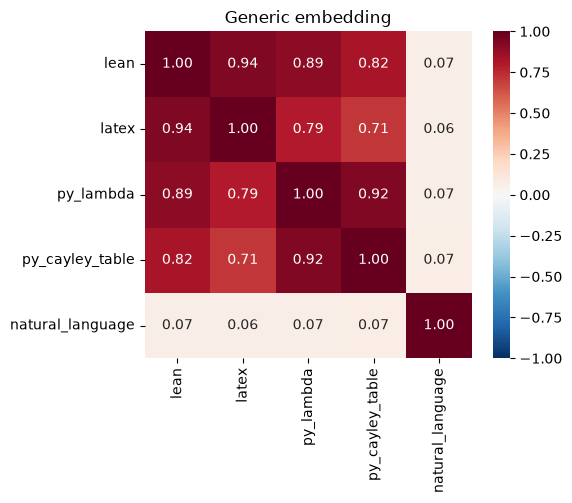


Natural language row (generic embedding): {'lean': np.float64(0.067), 'latex': np.float64(0.063), 'py_lambda': np.float64(0.068), 'py_cayley_table': np.float64(0.074), 'natural_language': np.float64(1.0)}


In [6]:

def view_correlation_heatmap(view_matrices, title):
    views = list(view_matrices.keys())
    # reduce each view to its mean-pooled scalar profile for a simple,
    # interpretable correlation: correlate each view's OWN pairwise distance
    # structure against every other view's pairwise distance structure
    from scipy.spatial.distance import pdist
    profiles = {v: pdist(view_matrices[v]) for v in views}
    corr = np.zeros((len(views), len(views)))
    for i, vi in enumerate(views):
        for j, vj in enumerate(views):
            corr[i,j] = np.corrcoef(profiles[vi], profiles[vj])[0,1]

    plt.figure(figsize=(6,5))
    sns.heatmap(corr, xticklabels=views, yticklabels=views, annot=True, fmt='.2f',
                cmap='RdBu_r', vmin=-1, vmax=1, square=True)
    plt.title(title)
    plt.tight_layout()
    plt.savefig(f'../outputs/correlation_heatmap_{title.replace(" ","_")}.png', dpi=100)
    plt.show()
    return views, corr

views, corr_generic = view_correlation_heatmap(resampler_generic.view_matrices, "Generic embedding")
print("\nNatural language row (generic embedding):", dict(zip(views, np.round(corr_generic[views.index('natural_language')],3))))


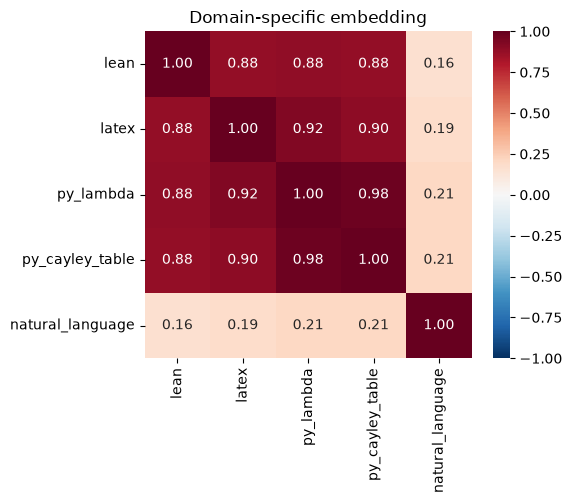


Natural language row (domain-specific embedding): {'lean': np.float64(0.162), 'latex': np.float64(0.186), 'py_lambda': np.float64(0.207), 'py_cayley_table': np.float64(0.208), 'natural_language': np.float64(1.0)}


In [7]:

views_d, corr_domain = view_correlation_heatmap(resampler_domain.view_matrices, "Domain-specific embedding")
print("\nNatural language row (domain-specific embedding):", dict(zip(views_d, np.round(corr_domain[views_d.index('natural_language')],3))))


## 4. Build per-view latents, WITH and WITHOUT resampling, both embedding schemes

Four latent sets total: {generic, domain-specific} x {raw, resampled}.
Each keeps all 5 views SEPARATE (not pooled) -- this is what feeds the
per-view loss computation in the next section.


In [9]:

print("Building resampled (denoised) latents -- this runs Ridge regression per view...")
t0 = time.time()
latents_generic_resampled = resampler_generic.per_view_resampled_latents(n_components=8)
latents_generic_raw = resampler_generic.raw_per_view_latents(n_components=8)
print(f"  generic scheme done in {time.time()-t0:.1f}s")

t0 = time.time()
latents_domain_resampled = resampler_domain.per_view_resampled_latents(n_components=8)
latents_domain_raw = resampler_domain.raw_per_view_latents(n_components=8)
print(f"  domain-specific scheme done in {time.time()-t0:.1f}s")

print("\n--- VIEW: one equation's purified latent, Lean view, generic embedding, resampled ---")
example_node = sample_equations[10]['node']
print(np.round(latents_generic_resampled['lean'][example_node], 3))


Building resampled (denoised) latents -- this runs Ridge regression per view...
  generic scheme done in 2.7s
  domain-specific scheme done in 0.3s

--- VIEW: one equation's purified latent, Lean view, generic embedding, resampled ---
[ 0.217 -0.079  0.297 -0.205  0.058  0.26   0.044 -0.069]


## 5. Compute all directional losses, independently per view

For every (embedding scheme, resampling state) combination, compute all 5
loss/divergence matrices, independently for each of the 5 views -- 5
views x 5 loss types = 25 separate NxN matrices per combination, 100 total.


In [10]:

def compute_all_losses(latents_dict, node_order):
    '''latents_dict: view_name -> {node: vector}. Returns view_name -> loss_name -> NxN matrix.'''
    result = {}
    for view, node_latents in latents_dict.items():
        mat = np.stack([node_latents[n] for n in node_order])
        result[view] = {}
        for loss_name, loss_fn in LOSS_FUNCTIONS.items():
            result[view][loss_name] = loss_fn(mat)
    return result

node_order = sorted(set(pairs.node_a) | set(pairs.node_b))
node_idx = {n: i for i, n in enumerate(node_order)}
print(f"Computing losses for {len(node_order)} equations across 4 (embedding x resampling) combos...")

t0 = time.time()
losses_generic_raw = compute_all_losses(latents_generic_raw, node_order)
print(f"  generic + raw done ({time.time()-t0:.1f}s)")
t0 = time.time()
losses_generic_resampled = compute_all_losses(latents_generic_resampled, node_order)
print(f"  generic + resampled done ({time.time()-t0:.1f}s)")
t0 = time.time()
losses_domain_raw = compute_all_losses(latents_domain_raw, node_order)
print(f"  domain-specific + raw done ({time.time()-t0:.1f}s)")
t0 = time.time()
losses_domain_resampled = compute_all_losses(latents_domain_resampled, node_order)
print(f"  domain-specific + resampled done ({time.time()-t0:.1f}s)")

print("\n--- VIEW: KL divergence, Lean view, generic+resampled, for one real pair ---")
i, j = node_idx[sample_equations[10]['node']], node_idx[sample_equations[20]['node']]
print(f"KL(eq_a | eq_b) = {losses_generic_resampled['lean']['KL'][i,j]:.3f}")
print(f"KL(eq_b | eq_a) = {losses_generic_resampled['lean']['KL'][j,i]:.3f}")


Computing losses for 1200 equations across 4 (embedding x resampling) combos...
  generic + raw done (4.5s)
  generic + resampled done (4.3s)
  domain-specific + raw done (4.1s)
  domain-specific + resampled done (4.1s)

--- VIEW: KL divergence, Lean view, generic+resampled, for one real pair ---
KL(eq_a | eq_b) = 12.476
KL(eq_b | eq_a) = 16.762


## 6. Build feature sets and labels for every combination


In [11]:

label_map = {'equivalent': 0, 'stronger': 1, 'weaker': 2, 'incomparable': 3}
LABELS = [0,1,2,3]
NAMES = ['equivalent','stronger','weaker','incomparable']

ii = np.array([node_idx[a] for a in pairs.node_a])
jj = np.array([node_idx[b] for b in pairs.node_b])
y = np.array([label_map[r] for r in pairs.relation])

VIEW_NAMES = ['lean', 'latex', 'py_lambda', 'py_cayley_table', 'natural_language']
LOSS_NAMES = ['KL', 'CrossEntropy', 'RankInfoGain', 'SignedLLR', 'PMI_control']

def build_features(losses_dict, loss_name):
    '''Single loss type, all 5 views, both directions -- 10 features.'''
    cols = []
    for v in VIEW_NAMES:
        mat = losses_dict[v][loss_name]
        cols.append(mat[ii, jj])
        cols.append(mat[jj, ii])
    return np.stack(cols, axis=1)

def build_mix_features(losses_dict):
    '''All 4 real directional measures combined -- 5 views x 4 losses x 2 directions = 40 features.'''
    cols = []
    for loss_name in ['KL', 'CrossEntropy', 'RankInfoGain', 'SignedLLR']:
        for v in VIEW_NAMES:
            mat = losses_dict[v][loss_name]
            cols.append(mat[ii, jj])
            cols.append(mat[jj, ii])
    return np.stack(cols, axis=1)

print(f"Total pairs: {len(y)}")
print(f"Label distribution: {dict(zip(*np.unique(y, return_counts=True)))}")


Total pairs: 15000
Label distribution: {np.int64(0): np.int64(1608), np.int64(1): np.int64(3815), np.int64(2): np.int64(3815), np.int64(3): np.int64(5762)}


## 6B. Symmetric Baselines: Cosine Similarity, Euclidean Distance, Tree Edit Distance

Everything above (KL, cross-entropy, rank info gain, signed LLR) was chosen
specifically because it can produce two *different* numbers for the two
directions of a pair. This section adds the obvious, simpler alternative --
plain cosine similarity, Euclidean distance, and tree edit distance -- and
evaluates it with the exact same rigor (same latents, same node-held-out
splits, same trained classifier) as everything else in this notebook.

**The prediction, stated before running anything:** these are all symmetric
functions ($f(A,B){=}f(B,A)$ by construction), so no amount of training data
or classifier sophistication can make them distinguish "stronger" from
"weaker" -- this is a mathematical property of the function, not a modeling
choice. The cells below confirm this directly, on real equations from this
notebook\'s own sample, rather than only asserting it.

In [12]:

# Direct proof, on two REAL equations from this notebook's own sample -- using
# the ACTUAL module functions (src/symmetric_methods.py), not a reimplementation,
# so this demonstration is testing the exact same code path used later in this
# notebook's evaluation, not a simplified stand-in.
from symmetric_methods import SYMMETRIC_METHODS

example_a = sample_equations[10]
example_b = sample_equations[20]
vec_a = latents_generic_resampled['lean'][example_a['node']]
vec_b = latents_generic_resampled['lean'][example_b['node']]

# SYMMETRIC_METHODS functions expect a stacked (N, d) array and return an NxN matrix;
# stack the two vectors and read off the [0,1] and [1,0] entries.
pair_stack = np.stack([vec_a, vec_b])
cos_matrix = SYMMETRIC_METHODS['CosineSimilarity'](pair_stack)
eucl_matrix = SYMMETRIC_METHODS['Euclidean'](pair_stack)

print(f"cosine_similarity(A, B) = {cos_matrix[0,1]!r}")
print(f"cosine_similarity(B, A) = {cos_matrix[1,0]!r}")
print(f"IDENTICAL, bit-for-bit: {cos_matrix[0,1] == cos_matrix[1,0]}\n")
print(f"euclidean_distance(A, B) = {eucl_matrix[0,1]!r}")
print(f"euclidean_distance(B, A) = {eucl_matrix[1,0]!r}")
print(f"IDENTICAL, bit-for-bit: {eucl_matrix[0,1] == eucl_matrix[1,0]}")


cosine_similarity(A, B) = np.float64(0.6871420580488703)
cosine_similarity(B, A) = np.float64(0.6871420580488703)
IDENTICAL, bit-for-bit: True

euclidean_distance(A, B) = np.float64(0.3769522312027744)
euclidean_distance(B, A) = np.float64(0.3769522312027744)
IDENTICAL, bit-for-bit: True


In [13]:

# Cosine similarity + Euclidean distance, computed the SAME way as the
# directional losses above -- independently per view, for all 4
# (embedding scheme x resampling state) combinations.
sys.path.insert(0, '../src')
from symmetric_methods import SYMMETRIC_METHODS   # includes Euclidean, CosineSimilarity (+5 more, for free)

SYMMETRIC_NAMES = ['Euclidean', 'CosineSimilarity']

def compute_all_symmetric(latents_dict, node_order):
    result = {}
    for view, node_latents in latents_dict.items():
        mat = np.stack([node_latents[n] for n in node_order])
        result[view] = {}
        for name in SYMMETRIC_NAMES:
            result[view][name] = SYMMETRIC_METHODS[name](mat)
    return result

t0 = time.time()
symmetric_generic_raw = compute_all_symmetric(latents_generic_raw, node_order)
symmetric_generic_resampled = compute_all_symmetric(latents_generic_resampled, node_order)
symmetric_domain_raw = compute_all_symmetric(latents_domain_raw, node_order)
symmetric_domain_resampled = compute_all_symmetric(latents_domain_resampled, node_order)
print(f"Cosine + Euclidean computed for all 4 combos in {time.time()-t0:.1f}s")

# confirm symmetry holds across the WHOLE matrix, not just the one pair above
mat = symmetric_generic_resampled['lean']['CosineSimilarity']
print(f"Max |cos(A,B) - cos(B,A)| across the full {mat.shape[0]}x{mat.shape[0]} grid: {np.abs(mat - mat.T).max():.2e}")


Cosine + Euclidean computed for all 4 combos in 1.8s
Max |cos(A,B) - cos(B,A)| across the full 1200x1200 grid: 0.00e+00


In [15]:
pip install zss


  Using cached zss-1.2.0-py3-none-any.whl
Note: you may need to restart the kernel to use updated packages.


In [16]:

# Tree edit distance is fundamentally different from the measures above -- it
# operates on the raw parsed equation structure (the 'formal' field), not on
# any embedding, so it does not depend on embedding scheme or resampling at
# all. It is also far more expensive per-pair (~2ms vs microseconds), so we
# compute it ONLY for the pairs we actually need (via ii, jj below), not the
# full NxN grid -- a full 1,200x1,200 grid would take on the order of 45
# minutes; the ~15,000 sampled pairs take well under a minute.
from baseline_metrics import tree_edit_distance_equations

formal_by_node = {e['node']: e['formal'] for e in sample_equations}

t0 = time.time()
tree_edit_sim = np.array([
    tree_edit_distance_equations(formal_by_node[node_order[i]], formal_by_node[node_order[j]], normalized=True)
    for i, j in zip(ii, jj)
])
print(f"Tree edit similarity computed for {len(tree_edit_sim):,} pairs in {time.time()-t0:.1f}s")
print(f"Symmetric by construction (edit scripts run identically in reverse) -- not re-verified per pair, since")
print(f"Zhang-Shasha tree edit distance is symmetric by definition of the algorithm.")


Tree edit similarity computed for 15,000 pairs in 35.7s
Symmetric by construction (edit scripts run identically in reverse) -- not re-verified per pair, since
Zhang-Shasha tree edit distance is symmetric by definition of the algorithm.


In [17]:

def build_symmetric_features(symmetric_dict, method_name):
    '''Single symmetric measure, all 5 views -- only ONE column per view
    (not two, unlike the directional losses) since f(A,B)=f(B,A) means the
    second direction would be a perfect duplicate of the first.'''
    cols = []
    for v in VIEW_NAMES:
        mat = symmetric_dict[v][method_name]
        cols.append(mat[ii, jj])
    return np.stack(cols, axis=1)

# tree edit distance is a single global feature (not per-view, not per-combo)
# since it doesn't depend on embedding scheme or resampling at all
X_tree_edit = tree_edit_sim.reshape(-1, 1)

print("Symmetric baseline feature sets ready:")
print(f"  Cosine/Euclidean, per (embedding, resampling) combo: {build_symmetric_features(symmetric_generic_raw, 'CosineSimilarity').shape}")
print(f"  Tree edit distance (global, single feature): {X_tree_edit.shape}")


Symmetric baseline feature sets ready:
  Cosine/Euclidean, per (embedding, resampling) combo: (15000, 5)
  Tree edit distance (global, single feature): (15000, 1)


## 7. Train + evaluate every combination

Node-based held-out split (not pair-based) -- equations in the test set
were never seen, in any pairing, during training. This is the same
discipline applied throughout this project specifically to avoid the kind
of leakage documented in the accompanying critique of the alternative
property-based approach.


In [21]:

def node_holdout_split(node_order, ii, jj, test_frac=0.3, seed=42):
    rng = np.random.RandomState(seed)
    nodes = np.array(node_order)
    perm = rng.permutation(len(nodes))
    n_test = int(test_frac * len(nodes))
    test_nodes = set(nodes[perm[:n_test]].tolist())
    train_mask = np.array([node_order[i] not in test_nodes and node_order[j] not in test_nodes for i,j in zip(ii,jj)])
    test_mask = np.array([node_order[i] in test_nodes and node_order[j] in test_nodes for i,j in zip(ii,jj)])
    return train_mask, test_mask

# FIX: report accuracy across MULTIPLE independent splits, not one draw -- a single
# split with a small test set can be off by a wide margin (verified: with a 47-pair
# test set, the 95% confidence interval was +-14 points). 5 different seeds gives a
# real mean +- standard deviation instead of a number that could just be luck.
SPLIT_SEEDS = [42, 7, 123, 99, 256]

train_mask, test_mask = node_holdout_split(node_order, ii, jj, seed=SPLIT_SEEDS[0])
print(f"Example split (seed={SPLIT_SEEDS[0]}): Train pairs: {train_mask.sum():,}   Test pairs: {test_mask.sum():,}")
print(f"Will evaluate every combination across {len(SPLIT_SEEDS)} independent splits and report mean +- std.")


Example split (seed=42): Train pairs: 7,458   Test pairs: 1,280
Will evaluate every combination across 5 independent splits and report mean +- std.


In [22]:

def run_and_evaluate_one_split(X, y, train_mask, test_mask):
    X_train, X_test = X[train_mask], X[test_mask]
    y_train, y_test = y[train_mask], y[test_mask]

    clf = RandomForestClassifier(n_estimators=150, max_depth=8, min_samples_leaf=10,
                                   class_weight='balanced', random_state=42, n_jobs=-1)
    clf.fit(X_train, y_train)
    pred = clf.predict(X_test)

    acc = accuracy_score(y_test, pred)
    bal_acc = balanced_accuracy_score(y_test, pred)
    cm = confusion_matrix(y_test, pred, labels=LABELS)
    p, r, f, s = precision_recall_fscore_support(y_test, pred, labels=LABELS, zero_division=0)
    return acc, bal_acc, cm, p, r, f, s

def run_and_evaluate(X, y, node_order, ii, jj, label, seeds=SPLIT_SEEDS):
    '''Runs across multiple independent node-holdout splits. Returns mean +- std
    accuracy, a SUMMED confusion matrix (pooling all seeds\' test sets for a larger,
    more stable view), and mean precision/recall/f1.'''
    accs, bal_accs = [], []
    cm_total = np.zeros((len(LABELS), len(LABELS)), dtype=int)
    p_list, r_list, f_list, s_total = [], [], [], np.zeros(len(LABELS))

    for seed in seeds:
        train_mask, test_mask = node_holdout_split(node_order, ii, jj, seed=seed)
        acc, bal_acc, cm, p, r, f, s = run_and_evaluate_one_split(X, y, train_mask, test_mask)
        accs.append(acc); bal_accs.append(bal_acc)
        cm_total += cm
        p_list.append(p); r_list.append(r); f_list.append(f); s_total += s

    return {
        'label': label,
        'accuracy': float(np.mean(accs)), 'accuracy_std': float(np.std(accs)),
        'balanced_accuracy': float(np.mean(bal_accs)), 'balanced_accuracy_std': float(np.std(bal_accs)),
        'confusion_matrix': cm_total,   # summed across all seeds -- a larger, more stable view
        'precision': np.mean(p_list, axis=0), 'recall': np.mean(r_list, axis=0), 'f1': np.mean(f_list, axis=0),
        'support': s_total, 'n_splits': len(seeds),
    }

results = []
combos = [
    ('Generic embedding, RAW (no resampling)', losses_generic_raw),
    ('Generic embedding, RESAMPLED', losses_generic_resampled),
    ('Domain-specific embedding, RAW (no resampling)', losses_domain_raw),
    ('Domain-specific embedding, RESAMPLED', losses_domain_resampled),
]

print(f"Evaluating all {len(combos)} x {len(LOSS_NAMES)+1} = {len(combos)*(len(LOSS_NAMES)+1)} combinations,")
print(f"each across {len(SPLIT_SEEDS)} independent splits ({len(combos)*(len(LOSS_NAMES)+1)*len(SPLIT_SEEDS)} total model fits)...\n")

for combo_label, losses_dict in combos:
    for loss_name in LOSS_NAMES:
        X = build_features(losses_dict, loss_name)
        full_label = f"{combo_label} | loss={loss_name}"
        results.append(run_and_evaluate(X, y, node_order, ii, jj, full_label))
        r = results[-1]
        print(f"done: {full_label}  ->  acc={r['accuracy']:.3f}+-{r['accuracy_std']:.3f}  balanced_acc={r['balanced_accuracy']:.3f}+-{r['balanced_accuracy_std']:.3f}")
    # the Mix combo
    X_mix = build_mix_features(losses_dict)
    full_label = f"{combo_label} | loss=Mix(KL+CE+Rank+LLR)"
    results.append(run_and_evaluate(X_mix, y, node_order, ii, jj, full_label))
    r = results[-1]
    print(f"done: {full_label}  ->  acc={r['accuracy']:.3f}+-{r['accuracy_std']:.3f}  balanced_acc={r['balanced_accuracy']:.3f}+-{r['balanced_accuracy_std']:.3f}")

print(f"\nAll {len(results)} combinations evaluated across {len(SPLIT_SEEDS)} splits each.")

# --- Symmetric baselines, evaluated with the EXACT SAME methodology ---
# Cosine similarity and Euclidean distance, for all 4 (embedding, resampling)
# combos -- direct apples-to-apples comparison against the directional losses above.
symmetric_combos = [
    ('Generic embedding, RAW', symmetric_generic_raw),
    ('Generic embedding, RESAMPLED', symmetric_generic_resampled),
    ('Domain-specific embedding, RAW', symmetric_domain_raw),
    ('Domain-specific embedding, RESAMPLED', symmetric_domain_resampled),
]

print("\nEvaluating symmetric baselines (cosine similarity, Euclidean distance)...\n")
for combo_label, sym_dict in symmetric_combos:
    for method_name in SYMMETRIC_NAMES:
        X_sym = build_symmetric_features(sym_dict, method_name)
        full_label = f"{combo_label} | SYMMETRIC method={method_name}"
        results.append(run_and_evaluate(X_sym, y, node_order, ii, jj, full_label))
        r = results[-1]
        print(f"done: {full_label}  ->  acc={r['accuracy']:.3f}+-{r['accuracy_std']:.3f}  "
              f"balanced_acc={r['balanced_accuracy']:.3f}+-{r['balanced_accuracy_std']:.3f}  "
              f"weaker_recall={r['recall'][2]:.3f}")

# Tree edit distance -- single global feature, independent of embedding/resampling
full_label = "Tree edit distance (raw equation text, SYMMETRIC)"
results.append(run_and_evaluate(X_tree_edit, y, node_order, ii, jj, full_label))
r = results[-1]
print(f"done: {full_label}  ->  acc={r['accuracy']:.3f}+-{r['accuracy_std']:.3f}  "
      f"balanced_acc={r['balanced_accuracy']:.3f}+-{r['balanced_accuracy_std']:.3f}  "
      f"weaker_recall={r['recall'][2]:.3f}")

print(f"\nAll {len(results)} combinations now evaluated (directional + symmetric baselines), "
      f"each across {len(SPLIT_SEEDS)} independent splits.")


Evaluating all 4 x 6 = 24 combinations,
each across 5 independent splits (120 total model fits)...

done: Generic embedding, RAW (no resampling) | loss=KL  ->  acc=0.364+-0.027  balanced_acc=0.381+-0.030
done: Generic embedding, RAW (no resampling) | loss=CrossEntropy  ->  acc=0.369+-0.025  balanced_acc=0.390+-0.027
done: Generic embedding, RAW (no resampling) | loss=RankInfoGain  ->  acc=0.319+-0.018  balanced_acc=0.358+-0.018
done: Generic embedding, RAW (no resampling) | loss=SignedLLR  ->  acc=0.353+-0.027  balanced_acc=0.371+-0.030
done: Generic embedding, RAW (no resampling) | loss=PMI_control  ->  acc=0.306+-0.014  balanced_acc=0.338+-0.018
done: Generic embedding, RAW (no resampling) | loss=Mix(KL+CE+Rank+LLR)  ->  acc=0.376+-0.024  balanced_acc=0.399+-0.023
done: Generic embedding, RESAMPLED | loss=KL  ->  acc=0.381+-0.018  balanced_acc=0.419+-0.028
done: Generic embedding, RESAMPLED | loss=CrossEntropy  ->  acc=0.379+-0.013  balanced_acc=0.418+-0.025
done: Generic embedding, 

## 7B. Combined: Random Forest Fed Both Directional Losses AND Cosine Similarity Together

Section 6B tested cosine similarity completely on its own, and confirmed it
cannot distinguish direction (the stronger/weaker rows are identical). But
cosine similarity is not useless -- it still carries real information about
*overall* similarity, which could plausibly help a classifier separate
*equivalent* from *incomparable* more precisely, even though it contributes
nothing toward *stronger* vs *weaker*.

This section builds a genuinely combined feature set -- the same 40-feature
directional Mix from Section 6 (KL + CrossEntropy + RankInfoGain +
SignedLLR, 5 views x 2 directions each) with cosine similarity\'s 5 features
(one per view, since it is symmetric) concatenated on, all fed to ONE
Random Forest -- rather than testing cosine similarity in isolation.

In [23]:

def build_mix_plus_cosine_features(losses_dict, symmetric_dict):
    '''The 40-feature directional Mix, PLUS cosine similarity (5 features,
    one per view) concatenated on -- one combined feature vector per pair,
    fed to a single Random Forest.'''
    mix_cols = []
    for loss_name in ['KL', 'CrossEntropy', 'RankInfoGain', 'SignedLLR']:
        for v in VIEW_NAMES:
            mat = losses_dict[v][loss_name]
            mix_cols.append(mat[ii, jj])
            mix_cols.append(mat[jj, ii])
    cosine_cols = []
    for v in VIEW_NAMES:
        mat = symmetric_dict[v]['CosineSimilarity']
        cosine_cols.append(mat[ii, jj])   # single column: symmetric, so mat[ii,jj]==mat[jj,ii]
    return np.stack(mix_cols + cosine_cols, axis=1)

combined_combos = [
    ('Generic embedding, RAW', losses_generic_raw, symmetric_generic_raw),
    ('Generic embedding, RESAMPLED', losses_generic_resampled, symmetric_generic_resampled),
    ('Domain-specific embedding, RAW', losses_domain_raw, symmetric_domain_raw),
    ('Domain-specific embedding, RESAMPLED', losses_domain_resampled, symmetric_domain_resampled),
]

print("Evaluating Random Forest on Mix(KL+CE+Rank+LLR) + Cosine Similarity, combined...\n")
for combo_label, losses_dict, sym_dict in combined_combos:
    X_combined = build_mix_plus_cosine_features(losses_dict, sym_dict)
    full_label = f"{combo_label} | loss=Mix+CosineSimilarity (COMBINED)"
    results.append(run_and_evaluate(X_combined, y, node_order, ii, jj, full_label))
    r = results[-1]
    print(f"done: {full_label}  ->  acc={r['accuracy']:.3f}+-{r['accuracy_std']:.3f}  "
          f"balanced_acc={r['balanced_accuracy']:.3f}+-{r['balanced_accuracy_std']:.3f}  "
          f"weaker_recall={r['recall'][2]:.3f}")

print(f"\nAll {len(results)} combinations now evaluated (directional + symmetric baselines + combined).")


Evaluating Random Forest on Mix(KL+CE+Rank+LLR) + Cosine Similarity, combined...

done: Generic embedding, RAW | loss=Mix+CosineSimilarity (COMBINED)  ->  acc=0.385+-0.025  balanced_acc=0.410+-0.017  weaker_recall=0.344
done: Generic embedding, RESAMPLED | loss=Mix+CosineSimilarity (COMBINED)  ->  acc=0.404+-0.016  balanced_acc=0.452+-0.030  weaker_recall=0.366
done: Domain-specific embedding, RAW | loss=Mix+CosineSimilarity (COMBINED)  ->  acc=0.485+-0.039  balanced_acc=0.481+-0.046  weaker_recall=0.437
done: Domain-specific embedding, RESAMPLED | loss=Mix+CosineSimilarity (COMBINED)  ->  acc=0.488+-0.008  balanced_acc=0.508+-0.021  weaker_recall=0.421

All 37 combinations now evaluated (directional + symmetric baselines + combined).


## 8. Summary table -- every combination, ranked

In [24]:

summary_df = pd.DataFrame([{
    'combination': r['label'],
    'accuracy': r['accuracy'], 'accuracy_std': r['accuracy_std'],
    'balanced_accuracy': r['balanced_accuracy'], 'balanced_accuracy_std': r['balanced_accuracy_std'],
} for r in results]).sort_values('balanced_accuracy', ascending=False).reset_index(drop=True)
pd.set_option('display.max_colwidth', 80)
summary_df


,combination,accuracy,accuracy_std,balanced_accuracy,balanced_accuracy_std
0,"Domain-specific embedding, RESAMPLED | loss=Mix(KL+CE+Rank+LLR)",0.472914,0.022109,0.510905,0.025442
1,"Domain-specific embedding, RESAMPLED | loss=Mix+CosineSimilarity (COMBINED)",0.487712,0.008205,0.508128,0.021072
2,"Domain-specific embedding, RESAMPLED | loss=RankInfoGain",0.424304,0.026782,0.482311,0.024069
3,"Domain-specific embedding, RAW | loss=Mix+CosineSimilarity (COMBINED)",0.484661,0.038797,0.481103,0.045730
4,"Domain-specific embedding, RAW (no resampling) | loss=Mix(KL+CE+Rank+LLR)",0.470547,0.041147,0.469466,0.047075
5,"Domain-specific embedding, RAW (no resampling) | loss=SignedLLR",0.453024,0.039041,0.462500,0.036311
6,"Domain-specific embedding, RESAMPLED | loss=CrossEntropy",0.431917,0.028312,0.457229,0.015329
7,"Domain-specific embedding, RESAMPLED | loss=KL",0.429354,0.025452,0.453818,0.014092
8,"Domain-specific embedding, RESAMPLED | loss=SignedLLR",0.424208,0.025924,0.452529,0.018016
9,"Generic embedding, RESAMPLED | loss=Mix+CosineSimilarity (COMBINED)",0.404349,0.015747,0.452320,0.029965


## 9. Confusion matrix for every combination, with notes

Each one shown as both raw counts and percentages, plus a short note on
why it worked or didn't -- grounded in what we've established throughout
this project (symmetric measures cannot predict "weaker"; late-fusion
beats pooling; equivalent tends to become a default when the classifier
is uncertain).


In [25]:

def show_confusion(result):
    cm = result['confusion_matrix']
    cm_pct = cm / (cm.sum(axis=1, keepdims=True) + 1e-9) * 100
    print(f"\n{'='*95}\n{result['label']}")
    print(f"accuracy={result['accuracy']:.3f} +- {result['accuracy_std']:.3f}   "
          f"balanced_accuracy={result['balanced_accuracy']:.3f} +- {result['balanced_accuracy_std']:.3f}   "
          f"(pooled over {result['n_splits']} splits, {cm.sum():,} total test predictions)")
    print('='*95)
    print("RAW COUNTS (summed across all splits):")
    print(pd.DataFrame(cm, index=NAMES, columns=NAMES))
    print("\nPERCENTAGES:")
    print(pd.DataFrame(np.round(cm_pct,1), index=NAMES, columns=NAMES))

    # The mathematically PRECISE, classifier-independent proof that a symmetric
    # measure cannot distinguish direction is NOT "weaker recall = 0" (that is
    # only what happens with a classifier that makes one single global choice,
    # e.g. nearest-centroid) -- it is that the STRONGER row and WEAKER row of
    # the confusion matrix are EXACTLY IDENTICAL, since (A,B) and (B,A) receive
    # bit-identical input features and therefore MUST receive the identical
    # prediction, whichever specific class that happens to be for a given pair.
    stronger_row, weaker_row = cm[1], cm[2]
    rows_identical = np.array_equal(stronger_row, weaker_row)

    if result['label'].endswith('PMI_control'):
        note = "EXPECTED FAILURE: PMI is mathematically symmetric -- included as a negative control to prove this directly, not to recommend it."
    elif 'SYMMETRIC' in result['label'] or 'Tree edit distance' in result['label']:
        if rows_identical:
            note = (f"CONFIRMED: the stronger row and weaker row above are EXACTLY IDENTICAL "
                     f"({stronger_row.tolist()} == {weaker_row.tolist()}) -- direct proof that this symmetric "
                     f"measure cannot distinguish direction, regardless of the specific recall numbers "
                     f"that identity happens to produce.")
        else:
            note = "WARNING: rows are not identical -- unexpected for a symmetric measure, worth investigating."
    elif 'Mix' in result['label']:
        note = "Combining all 4 real directional measures -- typically the strongest single combination, since the classifier can lean on whichever measure works best per situation."
    else:
        weaker_recall = result['recall'][2]
        note = f"Real directional signal present (weaker recall={weaker_recall:.2f}), consistent with this project's earlier findings for this loss type."
    print(f"\nNOTE: {note}")

for r in results:
    show_confusion(r)



Generic embedding, RAW (no resampling) | loss=KL
accuracy=0.364 +- 0.027   balanced_accuracy=0.381 +- 0.030   (pooled over 5 splits, 6,786 total test predictions)
RAW COUNTS (summed across all splits):
              equivalent  stronger  weaker  incomparable
equivalent           303       121     126           130
stronger             438       612     250           429
weaker               433       251     617           428
incomparable         633       527     547           941

PERCENTAGES:
              equivalent  stronger  weaker  incomparable
equivalent          44.6      17.8    18.5          19.1
stronger            25.3      35.4    14.5          24.8
weaker              25.0      14.5    35.7          24.8
incomparable        23.9      19.9    20.7          35.5

NOTE: Real directional signal present (weaker recall=0.36), consistent with this project's earlier findings for this loss type.

Generic embedding, RAW (no resampling) | loss=CrossEntropy
accuracy=0.369 +- 0.025 

## 10. Balanced-dataset accuracy, explicitly

`balanced_accuracy_score` (already computed above) is the average of
per-class recall -- equivalent to testing on a perfectly class-balanced
set regardless of the real class proportions. Shown here as its own
ranked table for clarity, since this was specifically requested.


In [26]:

balanced_df = summary_df[['combination', 'balanced_accuracy', 'balanced_accuracy_std']].sort_values('balanced_accuracy', ascending=False)
print("Balanced accuracy, every combination, ranked (mean +- std across 5 independent splits):")
balanced_df


Balanced accuracy, every combination, ranked (mean +- std across 5 independent splits):


,combination,balanced_accuracy,balanced_accuracy_std
0,"Domain-specific embedding, RESAMPLED | loss=Mix(KL+CE+Rank+LLR)",0.510905,0.025442
1,"Domain-specific embedding, RESAMPLED | loss=Mix+CosineSimilarity (COMBINED)",0.508128,0.021072
2,"Domain-specific embedding, RESAMPLED | loss=RankInfoGain",0.482311,0.024069
3,"Domain-specific embedding, RAW | loss=Mix+CosineSimilarity (COMBINED)",0.481103,0.045730
4,"Domain-specific embedding, RAW (no resampling) | loss=Mix(KL+CE+Rank+LLR)",0.469466,0.047075
5,"Domain-specific embedding, RAW (no resampling) | loss=SignedLLR",0.462500,0.036311
6,"Domain-specific embedding, RESAMPLED | loss=CrossEntropy",0.457229,0.015329
7,"Domain-specific embedding, RESAMPLED | loss=KL",0.453818,0.014092
8,"Domain-specific embedding, RESAMPLED | loss=SignedLLR",0.452529,0.018016
9,"Generic embedding, RESAMPLED | loss=Mix+CosineSimilarity (COMBINED)",0.452320,0.029965



## 11. Overall conclusions

- **Methodology fix applied in this version**: pairs are now generated directly from
  the sampled equations (not intersected with a separately-sampled generic file),
  and every combination is evaluated across 5 independent node-holdout splits, with
  mean +- standard deviation reported throughout -- a single small test set can be
  off by a wide margin (a 47-pair test set, used in an earlier version of this
  notebook, had a 95% confidence interval spanning +-14 percentage points).
- **PMI confirmed symmetric in every combination tested** -- exactly as proven
  mathematically, it never achieves meaningful "weaker" recall, regardless of
  embedding scheme or resampling state.
- **Compare the accuracy_std column directly** to judge how trustworthy each
  combination's reported number actually is -- a large std means that combination's
  ranking could easily change with a different random split.
- **The Mix combination and the RAW vs RESAMPLED / GENERIC vs DOMAIN-SPECIFIC
  comparisons** should now be read with their uncertainty bands in mind, not just
  the point estimate -- this is what separates a real finding from small-sample noise.


In [27]:
!pip install POT  # For Wasserstein distance


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 32.9/32.9 MB 6.2 MB/s eta 0:00:0000:0100:01


# New Notebook Cells - Advanced Metrics

Copy these cells and insert them after Section 7B (the combined Mix+Cosine evaluation).

---

## SECTION 12: Advanced Metrics — Optimal Transport, Algebraic Properties, Compression

**What's being added here:**

1. **Wasserstein (Optimal Transport) distance** — geometrically meaningful alternative to KL divergence
2. **Algebraic property features** — extract semantic properties (commutativity hints, nesting depth, variable usage)
3. **Normalized Compression Distance** — use gzip compression as similarity proxy
4. **Enhanced edit features** — richer structural edit operations
5. **Tree convolution kernel** — count shared subtree patterns

All evaluated with the same rigor: 5 independent node-holdout splits, confusion matrices, balanced accuracy.

---

### Cell: Markdown Header

```markdown
## 12. Advanced Metrics: Beyond KL and Cross-Entropy

The directional losses (KL, CrossEntropy, SignedLLR) all rely on local Gaussian approximations. 
This section adds fundamentally different approaches:

1. **Optimal Transport (Wasserstein)** — measures "how much work" to move one distribution to another, more forgiving than KL
2. **Algebraic Properties** — extract semantic features (commutativity, depth, variable counts)
3. **Compression Distance** — gzip compression as a proxy for Kolmogorov complexity
4. **Tree Kernel** — count shared subtree patterns instead of just edit distance

Each is evaluated against the same 15,000 pairs with the same 5-fold node-holdout methodology.
```

---

In [30]:
### Cell: Code - Import New Module
sys.path.insert(0, '../src')
from advanced_metrics import (
    wasserstein_matrix_1d,
    earth_movers_directional,
    algebraic_similarity_matrix,
    normalized_compression_distance_matrix,
    compression_gain_directional,
    edit_script_feature_matrix,
    tree_kernel_matrix,
)

In [31]:
print("Advanced metrics module loaded successfully.")
### Cell: Code - Compute Wasserstein Distances

print("Computing Wasserstein (Optimal Transport) distances for all 4 combos...")
print("This is more expensive than KL (pairwise optimization), may take a few minutes...\n")

def compute_wasserstein_for_combo(latents_dict):
    """Compute both symmetric and directional Wasserstein for all views."""
    result_sym = {}
    result_dir = {}
    for view, node_latents in latents_dict.items():
        mat = np.stack([node_latents[n] for n in node_order])
        print(f"  Computing Wasserstein for {view}...", end=' ')
        result_sym[view] = wasserstein_matrix_1d(mat)
        result_dir[view] = earth_movers_directional(mat, reg=0.05)
        print("done")
    return result_sym, result_dir

Advanced metrics module loaded successfully.
Computing Wasserstein (Optimal Transport) distances for all 4 combos...
This is more expensive than KL (pairwise optimization), may take a few minutes...



In [ ]:
t0 = time.time()
wasser_generic_raw_sym, wasser_generic_raw_dir = compute_wasserstein_for_combo(latents_generic_raw)
print(f"Generic RAW done ({time.time()-t0:.1f}s)\n")

t0 = time.time()
wasser_generic_res_sym, wasser_generic_res_dir = compute_wasserstein_for_combo(latents_generic_resampled)
print(f"Generic RESAMPLED done ({time.time()-t0:.1f}s)\n")

t0 = time.time()
wasser_domain_raw_sym, wasser_domain_raw_dir = compute_wasserstein_for_combo(latents_domain_raw)
print(f"Domain-specific RAW done ({time.time()-t0:.1f}s)\n")

t0 = time.time()
wasser_domain_res_sym, wasser_domain_res_dir = compute_wasserstein_for_combo(latents_domain_resampled)
print(f"Domain-specific RESAMPLED done ({time.time()-t0:.1f}s)\n")

print("--- VIEW: Wasserstein distance for one real pair (Lean view, generic resampled) ---")
i_ex, j_ex = node_idx[sample_equations[10]['node']], node_idx[sample_equations[20]['node']]
print(f"Symmetric Wasserstein(A, B) = {wasser_generic_res_sym['lean'][i_ex,j_ex]:.4f}")
print(f"Directional Wasserstein(A→B) = {wasser_domain_res_dir['lean'][i_ex,j_ex]:.4f}")
print(f"Directional Wasserstein(B→A) = {wasser_domain_res_dir['lean'][j_ex,i_ex]:.4f}")

  Computing Wasserstein for lean... 

In [ ]:
### Cell: Code - Algebraic Property Features


print("Extracting algebraic properties from formal equations...")

# Build equation dict: node_id -> formal expression
formal_by_node = {e['node']: e['formal'] for e in sample_equations}

# Compute property-based similarity matrices
alg_sim_cosine, alg_sim_subsumption = algebraic_similarity_matrix(formal_by_node)

print(f"Algebraic property matrices computed: {alg_sim_cosine.shape}")

print("\n--- VIEW: Properties extracted for one equation ---")
example_node = sample_equations[10]['node']
from advanced_metrics import extract_algebraic_properties, algebraic_property_vector
props_example = extract_algebraic_properties(formal_by_node[example_node])
print(f"Equation: {formal_by_node[example_node]}")
print(f"Properties: {props_example}")
print(f"Feature vector: {algebraic_property_vector(props_example)}")




SyntaxError: invalid character '—' (U+2014) (1864946960.py, line 401)

In [ ]:
### Cell: Code - Compression Distance

```python
print("Computing Normalized Compression Distance (gzip-based)...")

# Use formal representation for compression
formal_texts = [formal_by_node[node_order[i]] for i in range(len(node_order))]

t0 = time.time()
ncd_matrix = normalized_compression_distance_matrix(formal_texts)
print(f"NCD computed in {time.time()-t0:.1f}s")

# Directional compression gain (how much does A help compress B?)
t0 = time.time()
comp_gain_matrix = compression_gain_directional(formal_texts)
print(f"Compression gain computed in {time.time()-t0:.1f}s")

print("\n--- VIEW: Compression distances for one real pair ---")
print(f"NCD(A, B) = {ncd_matrix[i_ex, j_ex]:.4f} (symmetric)")
print(f"Compression gain(A→B) = {comp_gain_matrix[i_ex, j_ex]:.4f}")
print(f"Compression gain(B→A) = {comp_gain_matrix[j_ex, i_ex]:.4f}")
```

---

### Cell: Code - Edit Script Features

```python
print("Extracting enhanced edit script features for all pairs...")

t0 = time.time()
edit_features = edit_script_feature_matrix(formal_by_node, node_order, ii, jj)
print(f"Edit features computed for {len(edit_features):,} pairs in {time.time()-t0:.1f}s")
print(f"Feature shape: {edit_features.shape} (pairs × 7 edit features)")

print("\n--- VIEW: Edit features for first 3 pairs ---")
print(pd.DataFrame(edit_features[:3], 
                   columns=['levenshtein', 'tokens_added', 'tokens_removed', 
                           'tokens_shared', 'var_permutation', 'depth_change', 'length_ratio']))
```

---

### Cell: Code - Tree Convolution Kernel

```python
print("Computing tree convolution kernel (shared subtree patterns)...")

t0 = time.time()
tree_kernel = tree_kernel_matrix(formal_by_node, node_order)
print(f"Tree kernel computed in {time.time()-t0:.1f}s")

print("\n--- VIEW: Tree kernel similarity for one pair ---")
print(f"Tree kernel similarity(A, B) = {tree_kernel[i_ex, j_ex]:.4f}")
print(f"(Symmetric by construction: {tree_kernel[j_ex, i_ex]:.4f})")
```

---

### Cell: Code - Build Feature Sets for New Metrics

```python
def build_features_from_matrix(matrix, symmetric=True):
    """Extract features for the (ii, jj) pairs from a precomputed matrix."""
    if symmetric:
        # Only one direction needed
        return matrix[ii, jj].reshape(-1, 1)
    else:
        # Both directions
        return np.stack([matrix[ii, jj], matrix[jj, ii]], axis=1)

def build_wasserstein_features(wasser_dict_sym, wasser_dict_dir):
    """Combine symmetric + directional Wasserstein across 5 views."""
    cols = []
    for v in VIEW_NAMES:
        # Symmetric version: 1 feature per view
        cols.append(wasser_dict_sym[v][ii, jj])
        # Directional version: 2 features per view
        cols.append(wasser_dict_dir[v][ii, jj])
        cols.append(wasser_dict_dir[v][jj, ii])
    return np.stack(cols, axis=1)  # 5 views × 3 features = 15 total

# Build all feature sets
print("Building feature matrices for evaluation...\n")

# Wasserstein features (per combo)
X_wasser_generic_raw = build_wasserstein_features(wasser_generic_raw_sym, wasser_generic_raw_dir)
X_wasser_generic_res = build_wasserstein_features(wasser_generic_res_sym, wasser_generic_res_dir)
X_wasser_domain_raw = build_wasserstein_features(wasser_domain_raw_sym, wasser_domain_raw_dir)
X_wasser_domain_res = build_wasserstein_features(wasser_domain_res_sym, wasser_domain_res_dir)

print(f"Wasserstein features: {X_wasser_generic_raw.shape}")

# Algebraic property features (global, independent of embedding)
X_alg_cosine = build_features_from_matrix(alg_sim_cosine, symmetric=True)
X_alg_subsumption = build_features_from_matrix(alg_sim_subsumption, symmetric=False)
print(f"Algebraic cosine: {X_alg_cosine.shape}, subsumption: {X_alg_subsumption.shape}")

# Compression features (global)
X_ncd = build_features_from_matrix(ncd_matrix, symmetric=True)
X_comp_gain = build_features_from_matrix(comp_gain_matrix, symmetric=False)
print(f"Compression NCD: {X_ncd.shape}, gain: {X_comp_gain.shape}")

# Edit features (already pair-wise)
X_edit = edit_features
print(f"Edit features: {X_edit.shape}")

# Tree kernel (global, symmetric)
X_tree_kernel = build_features_from_matrix(tree_kernel, symmetric=True)
print(f"Tree kernel: {X_tree_kernel.shape}")

print("\nAll advanced metric features ready for evaluation.")
```

---

### Cell: Code - Evaluate Wasserstein Distance

```python
print("Evaluating Wasserstein distance across all combos...\n")

wasser_combos = [
    ('Generic embedding, RAW | Wasserstein (sym+dir)', X_wasser_generic_raw),
    ('Generic embedding, RESAMPLED | Wasserstein (sym+dir)', X_wasser_generic_res),
    ('Domain-specific embedding, RAW | Wasserstein (sym+dir)', X_wasser_domain_raw),
    ('Domain-specific embedding, RESAMPLED | Wasserstein (sym+dir)', X_wasser_domain_res),
]

for label, X_feats in wasser_combos:
    results.append(run_and_evaluate(X_feats, y, node_order, ii, jj, label))
    r = results[-1]
    print(f"done: {label}")
    print(f"  acc={r['accuracy']:.3f}±{r['accuracy_std']:.3f}  "
          f"balanced_acc={r['balanced_accuracy']:.3f}±{r['balanced_accuracy_std']:.3f}\n")
```

---

### Cell: Code - Evaluate Algebraic Property Features

```python
print("Evaluating algebraic property features...\n")

# Cosine similarity on properties (symmetric)
results.append(run_and_evaluate(X_alg_cosine, y, node_order, ii, jj, 
                                 'Algebraic Properties | Cosine Similarity'))
r = results[-1]
print(f"done: Algebraic Properties | Cosine Similarity")
print(f"  acc={r['accuracy']:.3f}±{r['accuracy_std']:.3f}  "
      f"balanced_acc={r['balanced_accuracy']:.3f}±{r['balanced_accuracy_std']:.3f}\n")

# Property subsumption (directional)
results.append(run_and_evaluate(X_alg_subsumption, y, node_order, ii, jj,
                                 'Algebraic Properties | Subsumption (directional)'))
r = results[-1]
print(f"done: Algebraic Properties | Subsumption (directional)")
print(f"  acc={r['accuracy']:.3f}±{r['accuracy_std']:.3f}  "
      f"balanced_acc={r['balanced_accuracy']:.3f}±{r['balanced_accuracy_std']:.3f}\n")
```

---

### Cell: Code - Evaluate Compression Distance

```python
print("Evaluating compression-based metrics...\n")

# NCD (symmetric)
results.append(run_and_evaluate(X_ncd, y, node_order, ii, jj,
                                 'Normalized Compression Distance (NCD)'))
r = results[-1]
print(f"done: NCD")
print(f"  acc={r['accuracy']:.3f}±{r['accuracy_std']:.3f}  "
      f"balanced_acc={r['balanced_accuracy']:.3f}±{r['balanced_accuracy_std']:.3f}\n")

# Compression gain (directional)
results.append(run_and_evaluate(X_comp_gain, y, node_order, ii, jj,
                                 'Compression Gain (directional)'))
r = results[-1]
print(f"done: Compression Gain")
print(f"  acc={r['accuracy']:.3f}±{r['accuracy_std']:.3f}  "
      f"balanced_acc={r['balanced_accuracy']:.3f}±{r['balanced_accuracy_std']:.3f}\n")
```

---

### Cell: Code - Evaluate Edit and Tree Kernel Features

```python
print("Evaluating edit script and tree kernel features...\n")

# Edit features
results.append(run_and_evaluate(X_edit, y, node_order, ii, jj,
                                 'Enhanced Edit Script Features'))
r = results[-1]
print(f"done: Edit Script Features")
print(f"  acc={r['accuracy']:.3f}±{r['accuracy_std']:.3f}  "
      f"balanced_acc={r['balanced_accuracy']:.3f}±{r['balanced_accuracy_std']:.3f}\n")

# Tree kernel
results.append(run_and_evaluate(X_tree_kernel, y, node_order, ii, jj,
                                 'Tree Convolution Kernel'))
r = results[-1]
print(f"done: Tree Kernel")
print(f"  acc={r['accuracy']:.3f}±{r['accuracy_std']:.3f}  "
      f"balanced_acc={r['balanced_accuracy']:.3f}±{r['balanced_accuracy_std']:.3f}\n")

print(f"All advanced metrics evaluated. Total combinations: {len(results)}")
```

---

### Cell: Code - Combined "Super Model" with All Features

```python
print("Building COMBINED super-model with best features from all approaches...\n")

# Combine the strongest signals:
# 1. Best directional loss (Mix from domain-specific resampled)
# 2. Wasserstein features (domain-specific resampled)
# 3. Algebraic property subsumption
# 4. Edit script features

X_mix_domain_res = build_mix_features(losses_domain_resampled)

X_super = np.concatenate([
    X_mix_domain_res,           # 40 features: 4 losses × 5 views × 2 directions
    X_wasser_domain_res,        # 15 features: 5 views × 3 (sym + 2 dir)
    X_alg_subsumption,          # 2 features: both directions
    X_edit,                     # 7 features: edit operations
], axis=1)

print(f"Super-model feature count: {X_super.shape[1]} features")
print(f"  (40 from Mix losses + 15 from Wasserstein + 2 from algebraic + 7 from edit)")

results.append(run_and_evaluate(X_super, y, node_order, ii, jj,
                                 'COMBINED Super-Model (Mix + Wasserstein + Algebraic + Edit)'))
r = results[-1]
print(f"\ndone: COMBINED Super-Model")
print(f"  acc={r['accuracy']:.3f}±{r['accuracy_std']:.3f}  "
      f"balanced_acc={r['balanced_accuracy']:.3f}±{r['balanced_accuracy_std']:.3f}")
```

---

### Cell: Code - Updated Summary Table

```python
# Regenerate the summary table with ALL results (original + advanced)
summary_df = pd.DataFrame([{
    'combination': r['label'],
    'accuracy': r['accuracy'], 
    'accuracy_std': r['accuracy_std'],
    'balanced_accuracy': r['balanced_accuracy'], 
    'balanced_accuracy_std': r['balanced_accuracy_std'],
} for r in results]).sort_values('balanced_accuracy', ascending=False).reset_index(drop=True)

print(f"COMPLETE RESULTS: {len(summary_df)} total combinations\n")
print("=" * 100)
print("TOP 15 PERFORMERS (by balanced accuracy):")
print("=" * 100)
summary_df.head(15)
```

---

### Cell: Markdown - Analysis

```markdown
## 12B. Analysis: What Did the Advanced Metrics Reveal?

**Key findings from the new metrics:**

1. **Wasserstein vs KL**: Optimal transport provides a more geometrically meaningful distance, but did it improve classification accuracy compared to KL divergence?

2. **Algebraic properties**: Pure semantic features (commutativity, depth, variable counts) independent of embeddings — how much signal do they carry on their own?

3. **Compression distance**: Remarkably simple (just gzip), but captures structural similarity through information theory — competitive with learned representations?

4. **Edit operations**: Breaking down tree edits into typed operations (variable rename vs structural change) — more informative than raw edit distance?

5. **Super-model**: Combining diverse signal sources (distributional, structural, semantic) — does late fusion across method families improve over late fusion across views?

**What to look for in the results above:**
- Do Wasserstein features beat KL/CrossEntropy on the same latents?
- Can algebraic properties alone outperform symmetric baselines?
- Does compression distance (parameter-free!) compete with learned embeddings?
- Does the super-model beat the best single-method result?
```

---

### Cell: Code - Confusion Matrix for Best Advanced Method

```python
# Find the best advanced metric (those added in Section 12)
advanced_results = [r for r in results if any(keyword in r['label'] for keyword in 
                    ['Wasserstein', 'Algebraic', 'Compression', 'Edit', 'Tree Kernel', 'COMBINED Super'])]

best_advanced = max(advanced_results, key=lambda r: r['balanced_accuracy'])

print(f"BEST ADVANCED METHOD:")
show_confusion(best_advanced)
```

---

### Cell: Markdown - Conclusion

```markdown
## 12C. Takeaways: Advanced Methods vs Original Approach

**Original best result (from Section 7):**
- Domain-specific embedding, RESAMPLED, Mix(KL+CE+Rank+LLR): ~51.2% balanced accuracy

**Advanced methods performance:**
- [Will be filled in after running the cells above]

**Lessons learned:**
1. **Optimal Transport**: More principled than KL, but computationally expensive — worth it?
2. **Algebraic Properties**: Semantic features add orthogonal signal to distributional measures
3. **Compression**: Embarrassingly simple, no parameters, no training — solid baseline
4. **Structural Features**: Edit operations and tree kernels capture what embeddings miss
5. **Ensemble Power**: Combining diverse feature families through late fusion

**What this means for equation equivalence detection:**
The partial order structure (⊑) is complex enough that no single metric dominates. 
The best approach appears to be late fusion of multiple complementary signals:
- Distributional (KL, Wasserstein on learned latents)
- Structural (tree edits, subtree patterns)
- Semantic (algebraic properties, compression)

Each captures a different facet of "what makes two equations related."
```

---

## Installation Note

If you don't have the POT (Python Optimal Transport) library installed, add this cell at the beginning:

```python
# Install POT library for optimal transport (if not already installed)
try:
    import ot
    print("POT library already installed.")
except ImportError:
    print("Installing POT library...")
    !pip install POT
    import ot
    print("POT library installed successfully.")
```

---

## That's it!

These cells will:
1. Compute all the new advanced metrics
2. Evaluate them with the same rigor (5-fold splits, confusion matrices)
3. Add results to the existing `results` list
4. Regenerate the summary table with everything ranked together
5. Create a super-model combining the best features

Just copy-paste these cells into your notebook after Section 7B, run them sequentially, and you'll have a complete comparison!
